### Assignment 1 (4 scores):

- Use Numpy only to construct the Logistic Regression model.
- Train and evaluating (precision, recall, f1) the Logistic Regression model using the Gradient Descent approach **to classify 0 and 1 digit images** on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Visualize the loss function of the training process.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import idx2numpy

In [5]:
images = idx2numpy.convert_from_file('train-images.idx3-ubyte')
labels = idx2numpy.convert_from_file('train-labels.idx1-ubyte')

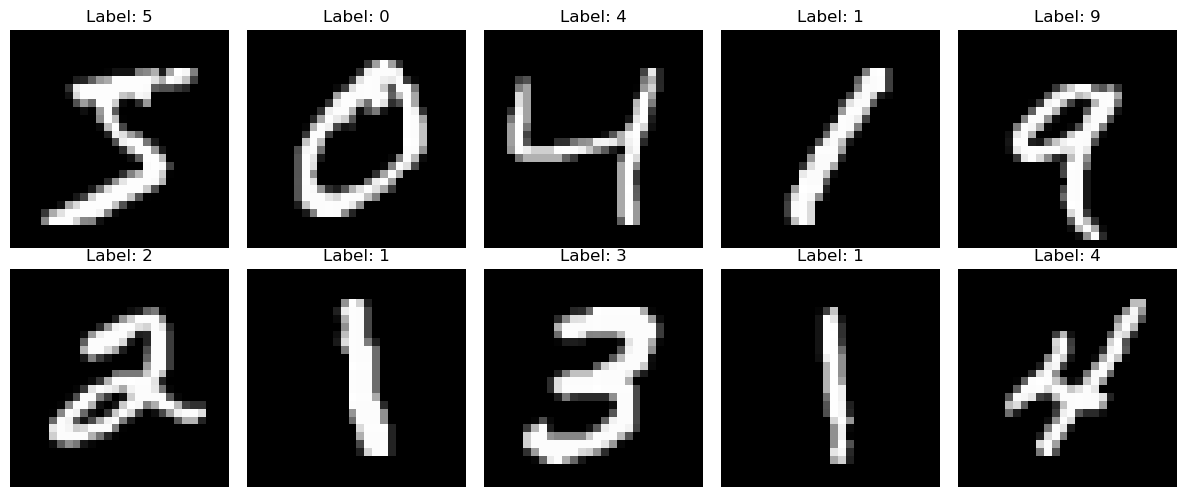

In [6]:
sample_images = images[:1000]
sample_labels = labels[:1000]

# Hiển thị một vài hình ảnh mẫu
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(sample_images[i], cmap='gray')
    axes[i].set_title(f'Label: {sample_labels[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
from tqdm import tqdm

class LogisticRegression:
    def __init__(self, learning_rate: float = 0.01, epochs: int = 100, threshold: float = 0.5):
        self.lr = learning_rate
        self.epochs = epochs
        self.threshold = threshold
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.metric_history = []

    def _sigmoid(self, z: np.ndarray) -> np.ndarray:
        # Giới hạn z trong khoảng [-500, 500] để tránh overflow hàm exp
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X: np.ndarray, y: np.ndarray, batch_size: int = 32):
        n_samples, n_features = X.shape
        
        # 1. Khởi tạo trọng số (Cần có Bias riêng nếu X không có cột số 1)
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        
        for epoch in tqdm(range(self.epochs), desc="Training Progress"):
            # 2. Shuffle dữ liệu mỗi epoch (Rất quan trọng trong Stochastic/Mini-batch)
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            for i in range(0, n_samples, batch_size):
                Xi = X_shuffled[i:i + batch_size]
                yi = y_shuffled[i:i + batch_size]
                
                # 3. Forward Pass: z = Xw + b
                z = np.dot(Xi, self.weights) + self.bias
                y_pred = self._sigmoid(z)
                
                # 4. Backward Pass (Tính Gradient)
                # Đạo hàm của Log Loss theo w và b
                error = y_pred - yi
                dw = (1 / len(yi)) * np.dot(Xi.T, error)
                db = (1 / len(yi)) * np.sum(error)
                
                # 5. Cập nhật (Bước 2 trong slide của bạn)
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
            
            # Lưu lại loss và metric cuối mỗi epoch để theo dõi
            y_pred_epoch = self.predict(X)
            current_loss = self._compute_loss(y, self.predict_proba(X))
            precision, recall, f1 = self._classification_metrics(y, y_pred_epoch)
            
            self.loss_history.append(current_loss)
            self.metric_history.append({
                "precision": precision,
                "recall": recall,
                "f1": f1
            })

    def _compute_loss(self, y_true, y_pred):
        # Thêm epsilon cực nhỏ để tránh log(0)
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def _classification_metrics(self, y_true: np.ndarray, y_pred: np.ndarray):
        y_true = y_true.astype(int).ravel()
        y_pred = y_pred.astype(int).ravel()

        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        precision = tp / (tp + fp + 1e-15)
        recall = tp / (tp + fn + 1e-15)
        f1 = 2 * precision * recall / (precision + recall + 1e-15)
        return precision, recall, f1

    def evaluate(self, X: np.ndarray, y: np.ndarray):
        y_pred = self.predict(X)
        precision, recall, f1 = self._classification_metrics(y, y_pred)
        return {
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # Trả về xác suất (dùng cho hàm score hoặc vẽ biểu đồ)
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Trả về nhãn 0 hoặc 1 (dùng cho thực tế)
        return (self.predict_proba(X) >= self.threshold).astype(int)

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        # Hàm đánh giá nhanh độ chính xác (Accuracy)
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [ ]:
# Load test set và tiền xử lý dữ liệu cho bài toán nhị phân 0/1
test_images = idx2numpy.convert_from_file('t10k-images.idx3-ubyte')
test_labels = idx2numpy.convert_from_file('t10k-labels.idx1-ubyte')

def preprocess_binary_mnist(images, labels, pos_label=1, neg_label=0):
    mask = (labels == pos_label) | (labels == neg_label)
    X = images[mask].astype(np.float32)
    y = labels[mask]

    # Chuẩn hóa và flatten
    X = (X / 255.0).reshape(X.shape[0], -1)
    y = (y == pos_label).astype(np.int32)
    return X, y

X_train, y_train = preprocess_binary_mnist(images, labels)
X_test, y_test = preprocess_binary_mnist(test_images, test_labels)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train class counts:', np.bincount(y_train))
print('Test class counts:', np.bincount(y_test))
print('Pixel range train:', X_train.min(), '->', X_train.max())

In [ ]:
# Train, evaluate và visualize loss
model = LogisticRegression(learning_rate=0.1, epochs=25, threshold=0.5)
model.fit(X_train, y_train, batch_size=128)

metrics = model.evaluate(X_test, y_test)
print('Precision:', round(metrics['precision'], 4))
print('Recall   :', round(metrics['recall'], 4))
print('F1-score :', round(metrics['f1'], 4))

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, color='tab:blue', lw=2)
plt.title('Logistic Regression Training Loss (MNIST 0 vs 1)')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(alpha=0.3)
plt.show()

# (Tùy chọn) xem metric ở epoch cuối cùng trên train
print('Last epoch train metrics:', model.metric_history[-1])

## Assignment 1 - Complete Pipeline (0 vs 1)

Tiền xử lý: lọc nhãn 0/1, flatten ảnh 28x28 -> 784, chuẩn hóa pixel về [0, 1].
Huấn luyện: Logistic Regression bằng mini-batch gradient descent (NumPy).
Đánh giá: Precision, Recall, F1 trên tập test và vẽ loss theo epoch.

### Assignment 2 (4 scores):

- Use Numpy only to construct the Softmax Regression model.
- Train and evaluating (precision, recall, f1) the Softmax Regression model using the Gradient Descent approach **to classify 10 digit images** on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Visualize the loss function of the training process.

### Assignment 3 (2 scores):

- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Logistic Regression on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Softmax Regression on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.